# Information Security - Assignment 1

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

os.makedirs("results", exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

os.makedirs("results", exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
train_path = "dataset/UNSW_NB15_training-set.csv"
test_path = "dataset/UNSW_NB15_testing-set.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (175341, 45)
Testing data shape: (82332, 45)


In [5]:
train_data.head()
train_data.info()
train_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service            175341 non-null  str    
 4   state              175341 non-null  str    
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  sinpkt       

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [6]:
print("Missing values in training data:")
print(train_data.isnull().sum())

print("\nTotal missing values:",
      train_data.isnull().sum().sum())

Missing values in training data:
id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
i

In [8]:
print("Duplicate training rows:", train_data.duplicated().sum())
print("Duplicate testing rows:", test_data.duplicated().sum())

Duplicate training rows: 0
Duplicate testing rows: 0


In [9]:
print("Duplicate training rows:", train_data.duplicated().sum())
print("Duplicate testing rows:", test_data.duplicated().sum())

Duplicate training rows: 0
Duplicate testing rows: 0


In [10]:
print(train_data["label"].value_counts(normalize=True) * 100)

label
1    68.062233
0    31.937767
Name: proportion, dtype: float64


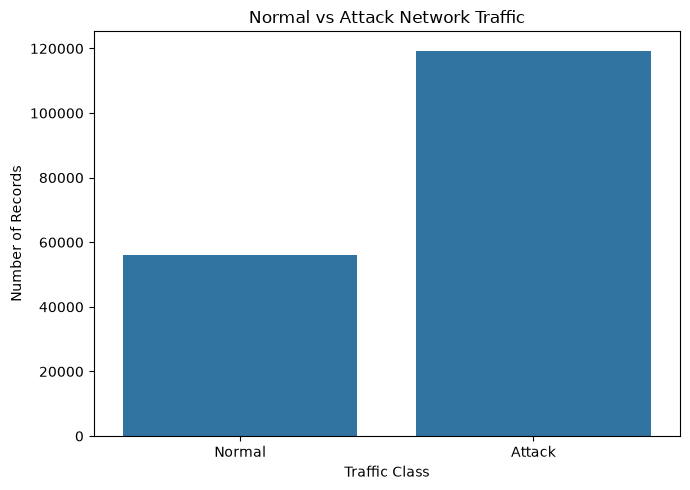

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=train_data,
    x="label"
)

plt.title("Normal vs Attack Network Traffic")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")
plt.xticks([0, 1], ["Normal", "Attack"])

plt.tight_layout()

plt.savefig(
    "results/class_distribution.png",
    dpi=300
)

plt.show()

In [12]:
attack_counts = (
    train_data["attack_cat"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .value_counts()
)

print(attack_counts)

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


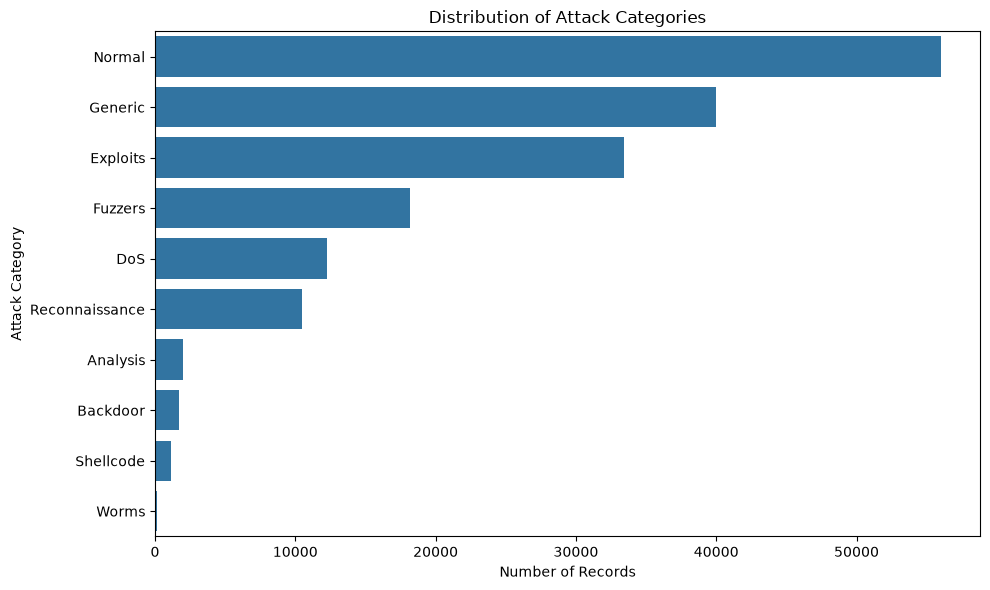

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=attack_counts.values,
    y=attack_counts.index
)

plt.title("Distribution of Attack Categories")
plt.xlabel("Number of Records")
plt.ylabel("Attack Category")

plt.tight_layout()

plt.savefig(
    "results/attack_categories.png",
    dpi=300
)

plt.show()

In [14]:
X_train = train_data.drop(
    columns=["label", "attack_cat"],
    errors="ignore"
)

y_train = train_data["label"].astype(int)

X_test = test_data.drop(
    columns=["label", "attack_cat"],
    errors="ignore"
)

y_test = test_data["label"].astype(int)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (175341, 43)
y_train: (175341,)
X_test: (82332, 43)
y_test: (82332,)


In [15]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 40
['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']

Categorical features: 3
['proto', 'service', 'state']


In [16]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf_model)
])

print("Random Forest model created!")

Random Forest model created!


In [19]:
pipeline.fit(
    X_train,
    y_train
)

print("Model training completed!")

Model training completed!


In [20]:
y_pred = pipeline.predict(X_test)

y_probability = pipeline.predict_proba(X_test)[:, 1]

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 82332


In [21]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 69.67%


In [22]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Attack Precision: {precision * 100:.2f}%")
print(f"Attack Recall: {recall * 100:.2f}%")
print(f"Attack F1-Score: {f1 * 100:.2f}%")

Attack Precision: 75.33%
Attack Recall: 66.79%
Attack F1-Score: 70.80%


In [23]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.64      0.73      0.68     37000
      Attack       0.75      0.67      0.71     45332

    accuracy                           0.70     82332
   macro avg       0.70      0.70      0.70     82332
weighted avg       0.70      0.70      0.70     82332



In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 27084
False Positives: 9916
False Negatives: 15056
True Positives : 30276


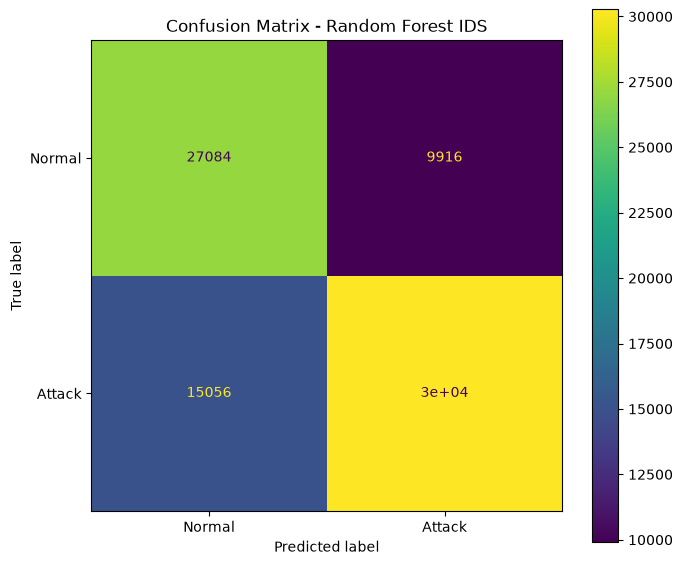

In [25]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot(ax=ax)

ax.set_title(
    "Confusion Matrix - Random Forest IDS"
)

plt.tight_layout()

plt.savefig(
    "results/confusion_matrix.png",
    dpi=300
)

plt.show()

In [26]:
attack_detection_rate = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

print(
    f"Attack Detection Rate: "
    f"{attack_detection_rate * 100:.2f}%"
)

print("\nSecurity Analysis")
print("-----------------")

print(
    "False negatives (missed attacks):",
    fn
)

print(
    "False positives (false alarms):",
    fp
)

Attack Detection Rate: 66.79%

Security Analysis
-----------------
False negatives (missed attacks): 15056
False positives (false alarms): 9916


In [27]:
feature_names = (
    pipeline
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

feature_importances = (
    pipeline
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
0,numeric__id,0.203772
29,numeric__ct_state_ttl,0.073982
7,numeric__sttl,0.046092
6,numeric__rate,0.045234
10,numeric__dload,0.035424
4,numeric__sbytes,0.033513
14,numeric__dinpkt,0.031454
1,numeric__dur,0.031385
23,numeric__ackdat,0.030930
9,numeric__sload,0.029999


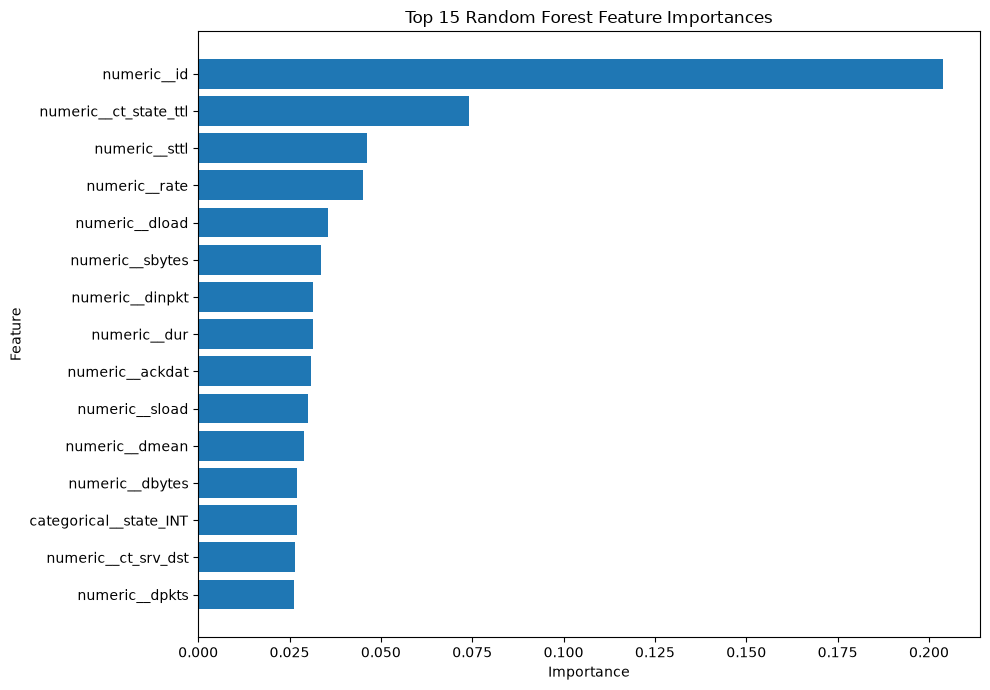

In [28]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "results/feature_importance.png",
    dpi=300
)

plt.show()

In [29]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Attack Precision",
        "Attack Recall",
        "Attack F1-Score",
        "Attack Detection Rate",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        attack_detection_rate,
        tn,
        fp,
        fn,
        tp
    ]
})

results

,Metric,Value
0,Accuracy,0.696691
1,Attack Precision,0.753284
2,Attack Recall,0.667873
3,Attack F1-Score,0.708012
4,Attack Detection Rate,0.667873
5,True Negatives,27084.000000
6,False Positives,9916.000000
7,False Negatives,15056.000000
8,True Positives,30276.000000


In [31]:
results.to_csv(
    "results/model_metrics.csv",
    index=False
)

print(
    "Metrics saved to results/model_metrics.csv"
)

Metrics saved to results/model_metrics.csv


In [32]:
joblib.dump(
    pipeline,
    "results/ids_random_forest_model.pkl"
)

print(
    "Trained model saved successfully!"
)

Trained model saved successfully!
